In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\User\Desktop\P\Car_sales.csv')

In [3]:
df.head()

,Manufacturer,Model,Sales in thousands,4-year resale value,Vehicle type,Price in thousands,Engine size,Horsepower,Wheelbase,Width,Length,Curb weight,Fuel capacity,Fuel efficiency,Latest Launch
0,Mitsubishi,3000GT,0.110,20.940000,Passenger,25.450,3.0,161.0,97.2,72.4,180.3,3.131,19.8,21.0,29-Jun-14
1,Dodge,Viper,0.916,58.470000,Passenger,69.725,8.0,450.0,96.2,75.7,176.7,3.375,19.0,16.0,08-Jul-15
2,Mercedes-Benz,CL500,0.954,18.072975,Passenger,85.500,5.0,302.0,113.6,73.1,196.6,4.115,23.2,20.0,04-Nov-15
3,Oldsmobile,Cutlass,1.112,11.240000,Passenger,18.145,3.1,150.0,107.0,69.4,192.0,3.102,15.2,25.0,31-May-15
4,Porsche,Carrera Coupe,1.280,60.625000,Passenger,71.020,3.4,300.0,92.6,69.5,174.5,3.032,17.0,21.0,21-Dec-14


In [4]:
df.shape

(157, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales in thousands   157 non-null    float64
 3   4-year resale value  157 non-null    float64
 4   Vehicle type         157 non-null    object 
 5   Price in thousands   155 non-null    float64
 6   Engine size          156 non-null    float64
 7   Horsepower           157 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb weight          155 non-null    float64
 12  Fuel capacity        156 non-null    float64
 13  Fuel efficiency      154 non-null    float64
 14  Latest Launch        157 non-null    object 
dtypes: float64(11), object(4)
memory usage: 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sales in thousands,157.0,52.998076,68.029422,0.110,14.1140,29.450,67.9560,540.561
4-year resale value,157.0,18.072975,10.045282,5.160,12.5450,17.710,18.1400,67.550
Price in thousands,155.0,27.390755,14.351653,9.235,18.0175,22.799,31.9475,85.500
Engine size,156.0,3.060897,1.044653,1.000,2.3000,3.000,3.5750,8.000
Horsepower,157.0,185.948718,56.518297,55.000,150.0000,180.000,215.0000,450.000
Wheelbase,156.0,107.487179,7.641303,92.600,103.0000,107.000,112.2000,138.700
Width,156.0,71.150000,3.451872,62.600,68.4000,70.550,73.4250,79.900
Length,156.0,187.343590,13.431754,149.400,177.5750,187.900,196.1250,224.500
Curb weight,155.0,3.378026,0.630502,1.895,2.9710,3.342,3.7995,5.572
Fuel capacity,156.0,17.951923,3.887921,10.300,15.8000,17.200,19.5750,32.000


In [7]:
df.isnull().any()

Manufacturer           False
Model                  False
Sales in thousands     False
4-year resale value    False
Vehicle type           False
Price in thousands      True
Engine size             True
Horsepower             False
Wheelbase               True
Width                   True
Length                  True
Curb weight             True
Fuel capacity           True
Fuel efficiency         True
Latest Launch          False
dtype: bool

In [8]:
df.dtypes

Manufacturer            object
Model                   object
Sales in thousands     float64
4-year resale value    float64
Vehicle type            object
Price in thousands     float64
Engine size            float64
Horsepower             float64
Wheelbase              float64
Width                  float64
Length                 float64
Curb weight            float64
Fuel capacity          float64
Fuel efficiency        float64
Latest Launch           object
dtype: object

In [9]:
df.isnull().sum().sort_values(ascending=False)

Fuel efficiency        3
Price in thousands     2
Curb weight            2
Engine size            1
Wheelbase              1
Width                  1
Length                 1
Fuel capacity          1
Manufacturer           0
Model                  0
Sales in thousands     0
4-year resale value    0
Vehicle type           0
Horsepower             0
Latest Launch          0
dtype: int64

In [10]:
#Missing value percentage
missing = df.isnull().mean().mul(100).sort_values(ascending=False)
missing

Fuel efficiency        1.910828
Price in thousands     1.273885
Curb weight            1.273885
Engine size            0.636943
Wheelbase              0.636943
Width                  0.636943
Length                 0.636943
Fuel capacity          0.636943
Manufacturer           0.000000
Model                  0.000000
Sales in thousands     0.000000
4-year resale value    0.000000
Vehicle type           0.000000
Horsepower             0.000000
Latest Launch          0.000000
dtype: float64

In [11]:
df.duplicated().sum()

0

In [12]:
#Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")

In [13]:
df.head()

,manufacturer,model,sales_in_thousands,4-year_resale_value,vehicle_type,price_in_thousands,engine_size,horsepower,wheelbase,width,length,curb_weight,fuel_capacity,fuel_efficiency,latest_launch
0,Mitsubishi,3000GT,0.110,20.940000,Passenger,25.450,3.0,161.0,97.2,72.4,180.3,3.131,19.8,21.0,29-Jun-14
1,Dodge,Viper,0.916,58.470000,Passenger,69.725,8.0,450.0,96.2,75.7,176.7,3.375,19.0,16.0,08-Jul-15
2,Mercedes-Benz,CL500,0.954,18.072975,Passenger,85.500,5.0,302.0,113.6,73.1,196.6,4.115,23.2,20.0,04-Nov-15
3,Oldsmobile,Cutlass,1.112,11.240000,Passenger,18.145,3.1,150.0,107.0,69.4,192.0,3.102,15.2,25.0,31-May-15
4,Porsche,Carrera Coupe,1.280,60.625000,Passenger,71.020,3.4,300.0,92.6,69.5,174.5,3.032,17.0,21.0,21-Dec-14


In [14]:
df['vehicle_type'].unique()

array(['Passenger', 'Car'], dtype=object)

In [15]:
#Check categorical variables
df['manufacturer'].nunique()

30

In [16]:
#Check unique manufacturers
df['manufacturer'].unique()

array(['Mitsubishi', 'Dodge', 'Mercedes-Benz', 'Oldsmobile', 'Porsche',
       'Audi', 'Plymouth', 'Lexus', 'Volvo', 'Saturn', 'Volkswagen',
       'Cadillac', 'Chrysler', 'Acura', 'Saab', 'BMW', 'Toyota', 'Honda',
       'Lincoln', 'Mercury', 'Jaguar', 'Chevrolet', 'Pontiac', 'Infiniti',
       'Nissan', 'Buick', 'Hyundai', 'Subaru', 'Ford', 'Jeep'],
      dtype=object)

In [17]:
#Check Vehicle type
df['vehicle_type'].value_counts().sort_values(ascending=False).head(10)

Passenger    116
Car           41
Name: vehicle_type, dtype: int64

In [18]:
#Date Conversion
df['latest_launch'] = pd.to_datetime(df['latest_launch'])

In [19]:
df['launch_year'] = df['latest_launch'].dt.year
df['launch_month'] = df['latest_launch'].dt.month

In [20]:
df.head()

,manufacturer,model,sales_in_thousands,4-year_resale_value,vehicle_type,price_in_thousands,engine_size,horsepower,wheelbase,width,length,curb_weight,fuel_capacity,fuel_efficiency,latest_launch,launch_year,launch_month
0,Mitsubishi,3000GT,0.110,20.940000,Passenger,25.450,3.0,161.0,97.2,72.4,180.3,3.131,19.8,21.0,2014-06-29,2014,6
1,Dodge,Viper,0.916,58.470000,Passenger,69.725,8.0,450.0,96.2,75.7,176.7,3.375,19.0,16.0,2015-07-08,2015,7
2,Mercedes-Benz,CL500,0.954,18.072975,Passenger,85.500,5.0,302.0,113.6,73.1,196.6,4.115,23.2,20.0,2015-11-04,2015,11
3,Oldsmobile,Cutlass,1.112,11.240000,Passenger,18.145,3.1,150.0,107.0,69.4,192.0,3.102,15.2,25.0,2015-05-31,2015,5
4,Porsche,Carrera Coupe,1.280,60.625000,Passenger,71.020,3.4,300.0,92.6,69.5,174.5,3.032,17.0,21.0,2014-12-21,2014,12


In [21]:
#Which manufactuer has the highest sales?
manufacturer_analysis = df.groupby("manufacturer")["sales_in_thousands"].sum().sort_values(ascending=False).head(1)
manufacturer_analysis

manufacturer
Ford    2022.635
Name: sales_in_thousands, dtype: float64

In [22]:
#Resale Retention% (What percentage of its original price does the vehicle retain after 4 years)
df['resale_retention%'] = (df['4-year_resale_value']/df['sales_in_thousands'])*100
df.head()

,manufacturer,model,sales_in_thousands,4-year_resale_value,vehicle_type,price_in_thousands,engine_size,horsepower,wheelbase,width,length,curb_weight,fuel_capacity,fuel_efficiency,latest_launch,launch_year,launch_month,resale_retention%
0,Mitsubishi,3000GT,0.110,20.940000,Passenger,25.450,3.0,161.0,97.2,72.4,180.3,3.131,19.8,21.0,2014-06-29,2014,6,19036.363636
1,Dodge,Viper,0.916,58.470000,Passenger,69.725,8.0,450.0,96.2,75.7,176.7,3.375,19.0,16.0,2015-07-08,2015,7,6383.187773
2,Mercedes-Benz,CL500,0.954,18.072975,Passenger,85.500,5.0,302.0,113.6,73.1,196.6,4.115,23.2,20.0,2015-11-04,2015,11,1894.441846
3,Oldsmobile,Cutlass,1.112,11.240000,Passenger,18.145,3.1,150.0,107.0,69.4,192.0,3.102,15.2,25.0,2015-05-31,2015,5,1010.791367
4,Porsche,Carrera Coupe,1.280,60.625000,Passenger,71.020,3.4,300.0,92.6,69.5,174.5,3.032,17.0,21.0,2014-12-21,2014,12,4736.328125


In [23]:
#Price per horsepower
df['price_per_horsepower'] = round(df['price_in_thousands']/df['horsepower'],2)
df.head()

,manufacturer,model,sales_in_thousands,4-year_resale_value,vehicle_type,price_in_thousands,engine_size,horsepower,wheelbase,width,length,curb_weight,fuel_capacity,fuel_efficiency,latest_launch,launch_year,launch_month,resale_retention%,price_per_horsepower
0,Mitsubishi,3000GT,0.110,20.940000,Passenger,25.450,3.0,161.0,97.2,72.4,180.3,3.131,19.8,21.0,2014-06-29,2014,6,19036.363636,0.16
1,Dodge,Viper,0.916,58.470000,Passenger,69.725,8.0,450.0,96.2,75.7,176.7,3.375,19.0,16.0,2015-07-08,2015,7,6383.187773,0.15
2,Mercedes-Benz,CL500,0.954,18.072975,Passenger,85.500,5.0,302.0,113.6,73.1,196.6,4.115,23.2,20.0,2015-11-04,2015,11,1894.441846,0.28
3,Oldsmobile,Cutlass,1.112,11.240000,Passenger,18.145,3.1,150.0,107.0,69.4,192.0,3.102,15.2,25.0,2015-05-31,2015,5,1010.791367,0.12
4,Porsche,Carrera Coupe,1.280,60.625000,Passenger,71.020,3.4,300.0,92.6,69.5,174.5,3.032,17.0,21.0,2014-12-21,2014,12,4736.328125,0.24


In [24]:
#KPIs
total_models = df['model'].nunique()
total_manufacturers = df['manufacturer'].nunique()
total_sales = df['sales_in_thousands'].sum()
avg_price = df['price_in_thousands'].mean()
avg_resale = df['4-year_resale_value'].mean()
avg_horsepower = df['horsepower'].mean()
avg_fuel_efficiency = df['fuel_efficiency'].mean()
avg_resale_retention = df['resale_retention%'].mean()

In [25]:
#KPI table
kpi_table = pd.Series({
    "Total Models": total_models,
    "Manufacturers" : total_manufacturers,
    "Total Sales (000s)": total_sales,
    "Average Price" : avg_price,
    "Average 4-year resale value": avg_resale,
    "Average Horsepower": avg_horsepower,
    "Average Fuel Efficiency" : avg_fuel_efficiency,
    "Average Resale Retention" : avg_resale_retention
})

kpi_table

Total Models                    156.000000
Manufacturers                    30.000000
Total Sales (000s)             8320.698000
Average Price                    27.390755
Average 4-year resale value      18.072975
Average Horsepower              185.948718
Average Fuel Efficiency          23.844156
Average Resale Retention        362.901957
dtype: float64

In [26]:
#Manufacturer Performance
manufacturer_analysis = df.groupby("manufacturer").agg(models=("model","nunique"),
                                                       sales=("sales_in_thousands","sum"),
                                                       avg_price=("price_in_thousands","mean"),
                                                       avg_resale=("4-year_resale_value","mean"),
                                                       avg_horsepower=("horsepower","mean"),
                                                        avg_fuel_efficiency=("fuel_efficiency","mean")
                                                       ).sort_values("sales",ascending=False) 


manufacturer_analysis.head(10)

,models,sales,avg_price,avg_resale,avg_horsepower,avg_fuel_efficiency
manufacturer,,,,,,
Ford,11,2022.635,21.047273,13.424816,170.090909,22.818182
Dodge,11,910.149,24.213636,16.961634,199.545455,20.100000
Toyota,9,740.205,21.982889,16.814775,160.666667,25.222222
Honda,5,592.674,20.277000,15.557000,160.400000,25.000000
Chevrolet,9,554.365,20.022778,13.768664,171.111111,28.444444
Nissan,7,399.635,22.360714,14.886564,169.000000,22.285714
Pontiac,6,370.534,22.949167,14.532163,185.000000,24.833333
Jeep,3,293.153,20.991667,15.353333,168.333333,18.666667
Buick,4,242.019,26.781250,14.941250,206.250000,24.250000


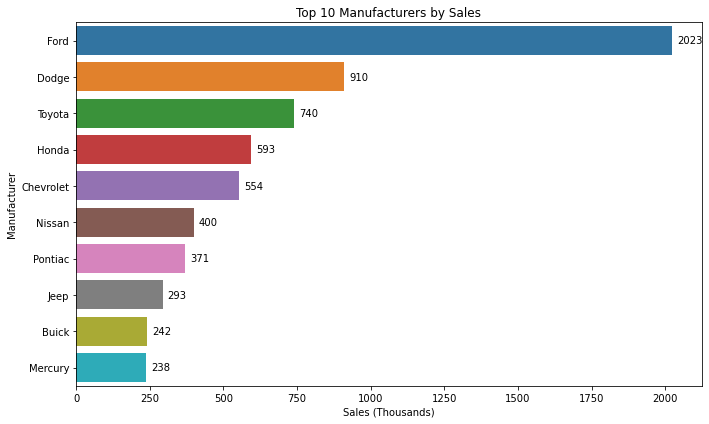

In [27]:
#Top Manufacturer by Sales
top_manufacturer = manufacturer_analysis.head(10).reset_index()
plt.figure(figsize=(10,6))
ax = sns.barplot(data=top_manufacturer,x="sales",y="manufacturer")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)

plt.title("Top 10 Manufacturers by Sales")
plt.xlabel("Sales (Thousands)")
plt.ylabel("Manufacturer")

plt.tight_layout()
plt.show()

In [28]:
#Best Selling Model
best_selling_model = df[["model","manufacturer","sales_in_thousands","price_in_thousands",
                         "4-year_resale_value"]].sort_values("sales_in_thousands",ascending=False).head(15)

best_selling_model

,model,manufacturer,sales_in_thousands,price_in_thousands,4-year_resale_value
156,F-Series,Ford,540.561,26.935,15.075000
155,Explorer,Ford,276.747,31.930,16.640000
154,Camry,Toyota,247.994,17.518,13.245000
153,Taurus,Ford,245.815,17.885,10.055000
152,Accord,Honda,230.902,15.350,13.210000
151,Ram Pickup,Dodge,227.061,19.460,15.060000
150,Ranger,Ford,220.650,12.050,7.850000
149,Civic,Honda,199.685,12.885,9.850000
148,Caravan,Dodge,181.749,19.565,12.025000
147,Focus,Ford,175.670,12.315,18.072975


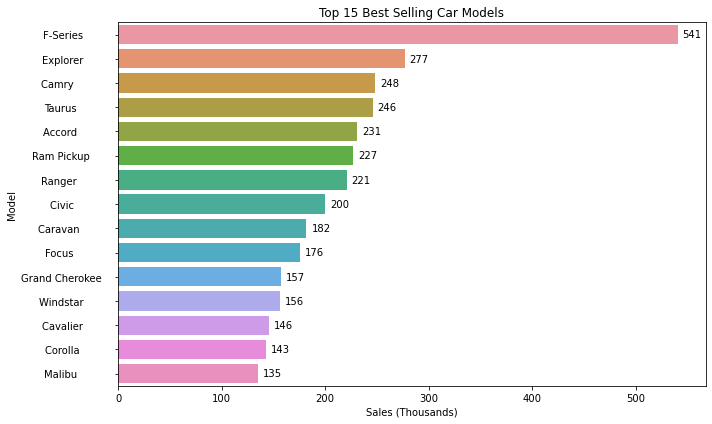

In [29]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=best_selling_model,x="sales_in_thousands",y="model")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)

plt.title("Top 15 Best Selling Car Models")
plt.xlabel("Sales (Thousands)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [30]:
#Are expensive cars actually selling well?
df[["manufacturer","model","price_in_thousands","horsepower",
    "sales_in_thousands"]].sort_values("price_in_thousands",ascending=False).head(15)

,manufacturer,model,price_in_thousands,horsepower,sales_in_thousands
2,Mercedes-Benz,CL500,85.500,302.0,0.954
9,Mercedes-Benz,SL-Class,82.600,302.0,3.311
7,Porsche,Carrera Cabriolet,74.970,300.0,1.866
4,Porsche,Carrera Coupe,71.020,300.0,1.280
1,Dodge,Viper,69.725,450.0,0.916
47,Mercedes-Benz,S-Class,69.700,275.0,16.774
5,Audi,A8,62.000,310.0,1.380
25,Lexus,LX470,60.105,230.0,9.126
18,Lexus,LS400,54.005,290.0,6.375
30,Toyota,Land Cruiser,51.728,230.0,9.835


In [31]:
#Resale Value analysis
resale_analysis = df[["manufacturer","model","price_in_thousands","4-year_resale_value",
    "resale_retention%"]].sort_values("resale_retention%",ascending=False).head(15)


resale_analysis

,manufacturer,model,price_in_thousands,4-year_resale_value,resale_retention%
0,Mitsubishi,3000GT,25.450,20.940000,19036.363636
1,Dodge,Viper,69.725,58.470000,6383.187773
4,Porsche,Carrera Coupe,71.020,60.625000,4736.328125
7,Porsche,Carrera Cabriolet,74.970,67.550000,3620.042872
5,Audi,A8,62.000,39.000000,2826.086957
2,Mercedes-Benz,CL500,85.500,18.072975,1894.441846
9,Mercedes-Benz,SL-Class,82.600,58.600000,1769.858049
6,Mercedes-Benz,SLK230,41.000,18.072975,1184.336514
3,Oldsmobile,Cutlass,18.145,11.240000,1010.791367
8,Plymouth,Prowler,43.000,18.072975,965.436710


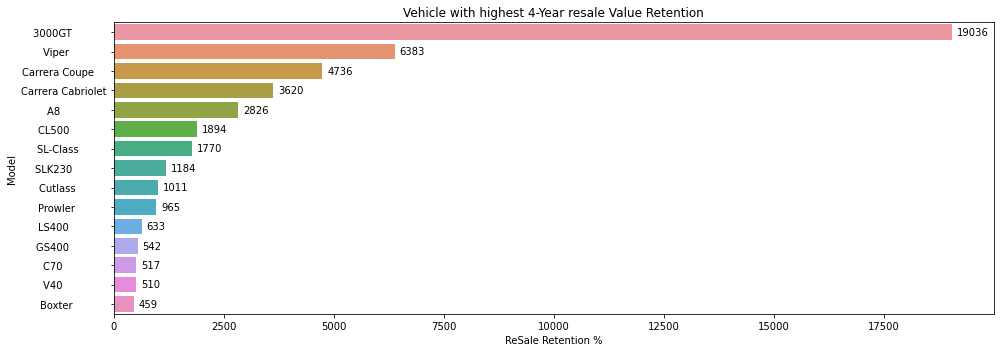

In [32]:
plt.figure(figsize=(14,5))
ax = sns.barplot(data=resale_analysis,x="resale_retention%",y="model")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)

plt.title("Vehicle with highest 4-Year resale Value Retention")
plt.xlabel("ReSale Retention %")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [33]:
#Vehicle Type Analysis
vehicle_type = df.groupby("vehicle_type").agg(models=("model","count"),
                                                       sales=("sales_in_thousands","sum"),
                                                       avg_price=("price_in_thousands","mean"),
                                                       avg_resale=("4-year_resale_value","mean"),
                                                       avg_horsepower=("horsepower","mean"),
                                                        avg_fuel_efficiency=("fuel_efficiency","mean")
                                                       )


vehicle_type.head(10)

,models,sales,avg_price,avg_resale,avg_horsepower,avg_fuel_efficiency
vehicle_type,,,,,,
Car,41,3305.514,26.319975,16.774091,186.388993,19.700000
Passenger,116,5015.184,27.763200,18.532064,185.793103,25.298246


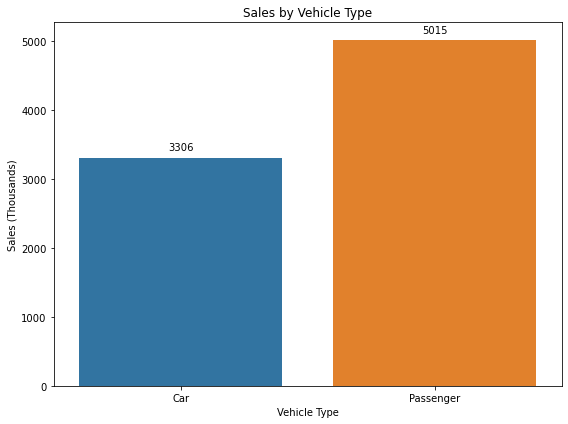

In [34]:
plt.figure(figsize=(8,6))
ax = sns.barplot(data=vehicle_type.reset_index(),x="vehicle_type",y="sales")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)

plt.title("Sales by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Sales (Thousands)")

plt.tight_layout()
plt.show()

In [35]:
#What drives sales?
num_cols = ["sales_in_thousands","price_in_thousands","4-year_resale_value","engine_size","horsepower","wheelbase","width","length","curb_weight","fuel_capacity","fuel_efficiency"]
corr = df[num_cols].corr()

corr

,sales_in_thousands,price_in_thousands,4-year_resale_value,engine_size,horsepower,wheelbase,width,length,curb_weight,fuel_capacity,fuel_efficiency
sales_in_thousands,1.000000,-0.304734,-0.266436,0.019983,-0.197756,0.358179,0.140918,0.254980,0.008628,0.086540,-0.016764
price_in_thousands,-0.304734,1.000000,0.822452,0.626875,0.839744,0.110513,0.329136,0.156935,0.526224,0.423282,-0.492157
4-year_resale_value,-0.266436,0.822452,1.000000,0.468813,0.696888,-0.047806,0.159591,0.023869,0.297929,0.275045,-0.358546
engine_size,0.019983,0.626875,0.468813,1.000000,0.837360,0.472130,0.690398,0.541424,0.760043,0.663022,-0.734622
horsepower,-0.197756,0.839744,0.696888,0.837360,1.000000,0.286308,0.539158,0.393364,0.610131,0.499907,-0.611332
wheelbase,0.358179,0.110513,-0.047806,0.472130,0.286308,1.000000,0.683135,0.839639,0.651016,0.654044,-0.497931
width,0.140918,0.329136,0.159591,0.690398,0.539158,0.683135,1.000000,0.710435,0.720927,0.656302,-0.602546
length,0.254980,0.156935,0.023869,0.541424,0.393364,0.839639,0.710435,1.000000,0.627163,0.563540,-0.446756
curb_weight,0.008628,0.526224,0.297929,0.760043,0.610131,0.651016,0.720927,0.627163,1.000000,0.863968,-0.818402
fuel_capacity,0.086540,0.423282,0.275045,0.663022,0.499907,0.654044,0.656302,0.563540,0.863968,1.000000,-0.801512


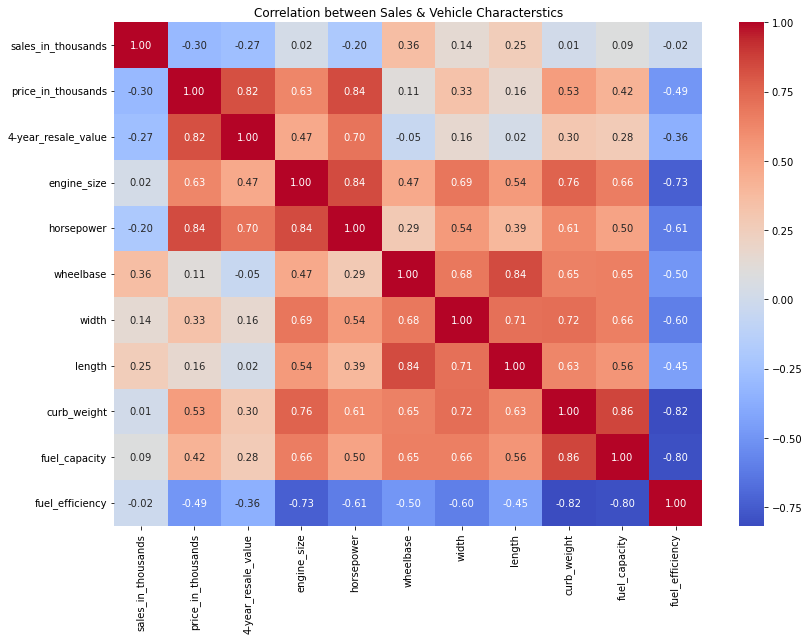

In [36]:
plt.figure(figsize=(12,9))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation between Sales & Vehicle Characterstics")

plt.tight_layout()
plt.show()

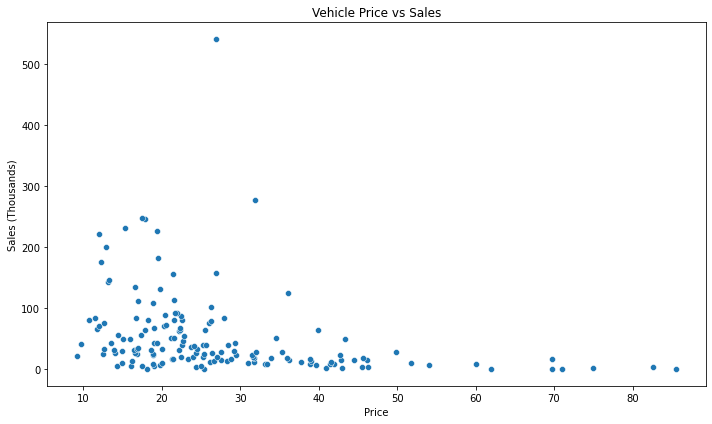

In [37]:
#Do lower price cars acheive higher sales volume?
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="price_in_thousands",y="sales_in_thousands")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)

plt.title("Vehicle Price vs Sales")
plt.xlabel("Price")
plt.ylabel("Sales (Thousands)")

plt.tight_layout()
plt.show()

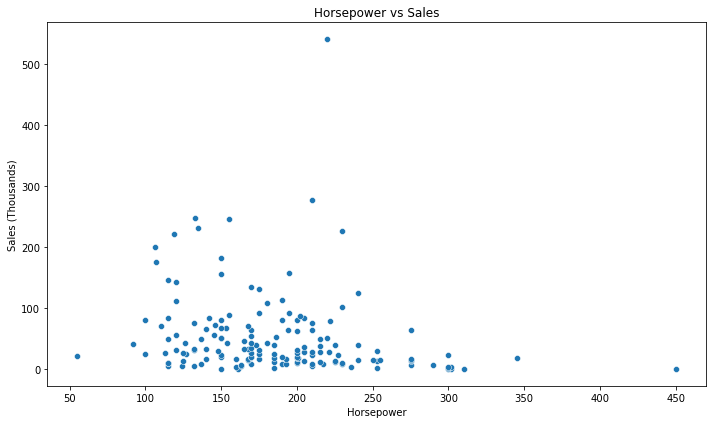

In [38]:
#Horsepower vs Sales
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="horsepower",y="sales_in_thousands")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)

plt.title("Horsepower vs Sales")
plt.xlabel("Horsepower")
plt.ylabel("Sales (Thousands)")

plt.tight_layout()
plt.show()

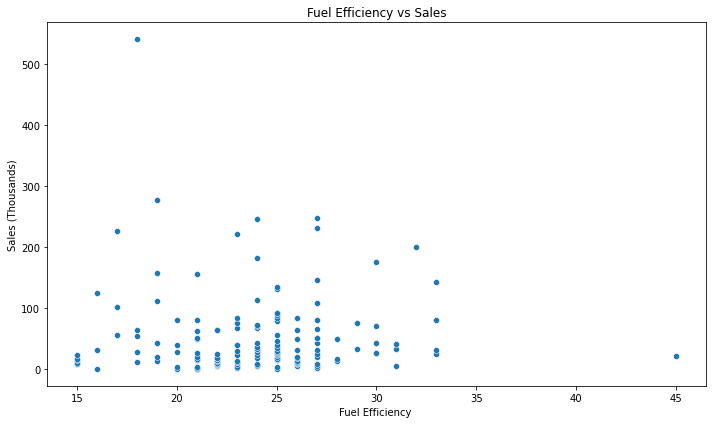

In [39]:
#Fuel Efficiency vs Sales
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="fuel_efficiency",y="sales_in_thousands")
ax.bar_label(ax.containers[0],fmt="%.0f",padding=5)

plt.title("Fuel Efficiency vs Sales")
plt.xlabel("Fuel Efficiency ")
plt.ylabel("Sales (Thousands)")

plt.tight_layout()
plt.show()

In [40]:
#Which vehicle provides the strongest performance relative to price?

df['horsepower_per_1000_dollars'] = df['horsepower']/df['price_in_thousands']

In [41]:
df[["manufacturer","model","price_in_thousands","horsepower","horsepower_per_1000_dollars",
    "sales_in_thousands"]].sort_values("horsepower_per_1000_dollars",ascending=False).head(15)

,manufacturer,model,price_in_thousands,horsepower,horsepower_per_1000_dollars,sales_in_thousands
131,Toyota,Tacoma,11.528,142.0,12.317835,84.087
116,Hyundai,Elantra,11.799,140.0,11.865412,66.692
151,Dodge,Ram Pickup,19.460,230.0,11.819116,227.061
123,Dodge,Neon,12.640,132.0,10.443038,76.034
84,Plymouth,Neon,12.640,132.0,10.443038,32.734
142,Chevrolet,Malibu,16.535,170.0,10.281222,135.126
88,Ford,Contour,17.035,170.0,9.979454,35.068
150,Ford,Ranger,12.050,119.0,9.875519,220.650
78,Hyundai,Sonata,14.999,148.0,9.867324,29.450
137,Chevrolet,Impala,18.890,180.0,9.528851,107.995


In [42]:
#summary
summary = df.groupby("manufacturer").agg(models=("model","count"),
                                                       sales=("sales_in_thousands","sum"),
                                                       avg_price=("price_in_thousands","mean"),
                                                       avg_resale=("4-year_resale_value","mean"),
                                                       resale_retention=("resale_retention%","mean"),
                                                        avg_horsepower=("horsepower","mean"),
                                                         avg_fuel_efficiency=("fuel_efficiency","mean")
                                                       ).reset_index()

summary.sort_values("sales",ascending=False).head(10)

,manufacturer,models,sales,avg_price,avg_resale,resale_retention,avg_horsepower,avg_fuel_efficiency
8,Ford,11,2022.635,21.047273,13.424816,11.221644,170.090909,22.818182
7,Dodge,11,910.149,24.213636,16.961634,623.962591,199.545455,20.100000
27,Toyota,9,740.205,21.982889,16.814775,61.593049,160.666667,25.222222
9,Honda,5,592.674,20.277000,15.557000,39.362008,160.400000,25.000000
5,Chevrolet,9,554.365,20.022778,13.768664,44.817533,171.111111,28.444444
19,Nissan,7,399.635,22.360714,14.886564,30.129296,169.000000,22.285714
22,Pontiac,6,370.534,22.949167,14.532163,36.934215,185.000000,24.833333
13,Jeep,3,293.153,20.991667,15.353333,17.777372,168.333333,18.666667
3,Buick,4,242.019,26.781250,14.941250,34.270453,206.250000,24.250000
17,Mercury,6,237.999,20.748333,13.970000,49.137797,163.833333,23.666667


In [43]:
#Automotive Market segmenataion using Price & Resale value

In [44]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.metrics import silhouette_score

In [51]:
data = df[['price_in_thousands','4-year_resale_value']]

In [52]:
data = data.dropna()

In [53]:
data.shape

(155, 2)

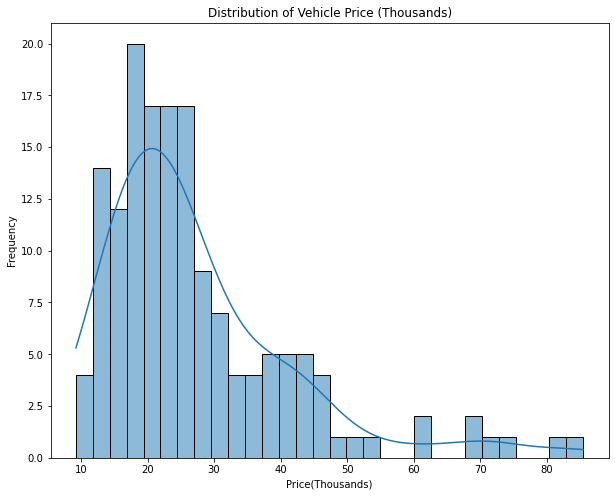

In [54]:
#Histogram for Price in thousands
plt.figure(figsize=(10,8))
sns.histplot(data['price_in_thousands'],bins=30,kde=True)
plt.title("Distribution of Vehicle Price (Thousands)")
plt.xlabel("Price(Thousands)")
plt.ylabel("Frequency")
plt.show()

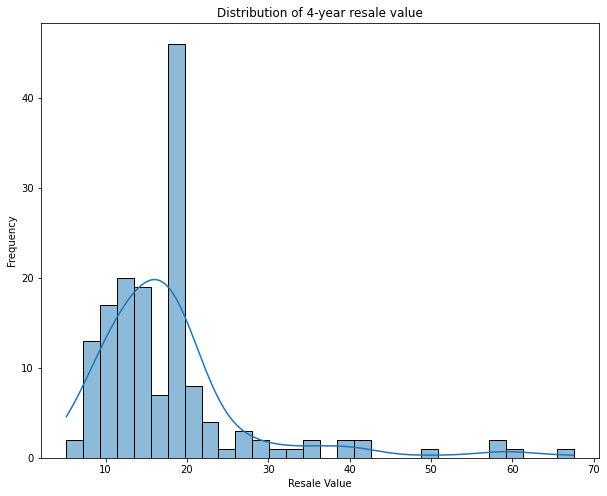

In [55]:
#Histogram for 4-year resale value
plt.figure(figsize=(10,8))
sns.histplot(data['4-year_resale_value'],bins=30,kde=True)
plt.title("Distribution of 4-year resale value")
plt.xlabel("Resale Value")
plt.ylabel("Frequency")
plt.show()

In [56]:
#Calculate Skewness
print("Price in thousands",data['price_in_thousands'].skew())
print("4-year resale value",data['4-year_resale_value'].skew())

Price in thousands 1.7657343310319031
4-year resale value 2.5938910276537914


In [57]:
#Log Transformation
data['price_in_thousands'] = np.log1p(data['price_in_thousands'])
data['4-year_resale_value'] = np.log1p(data['4-year_resale_value'])

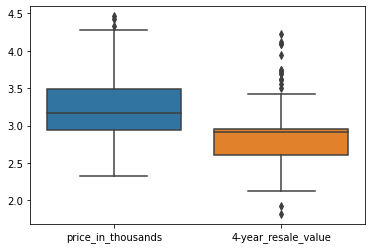

In [58]:
sns.boxplot(data=data[['price_in_thousands','4-year_resale_value']])
plt.show()

In [59]:
#IQR Method
Q1 = data.quantile(0.25)
Q3=data.quantile(0.75)
IQR = Q3-Q1
outliers = ((data<(Q1-1.5*IQR)) | (data>(Q3+1.5*IQR)))
print(outliers.sum())

price_in_thousands      3
4-year_resale_value    15
dtype: int64


In [60]:
#Display IQR rows
outlier_rows = data[outliers.any(axis=1)]
print(outlier_rows)

    price_in_thousands  4-year_resale_value
1             4.258799             4.085472
2             4.460144             2.948272
4             4.276944             4.121068
5             4.143135             3.688879
7             4.330339             4.227563
9             4.426044             4.087656
18            4.007424             3.722677
24            3.747856             3.743604
30            3.965147             3.557631
35            3.658549             3.498778
47            4.258446             3.939152
50            3.686376             3.614291
52            3.843851             3.616981
61            2.325813             1.818077
74            3.929863             3.748327
95            2.370150             1.925707


In [61]:
scaler = RobustScaler()
scaled_data = scaler.fit_transform(data)

In [62]:
data.head()

,price_in_thousands,4-year_resale_value
0,3.275256,3.088311
1,4.258799,4.085472
2,4.460144,2.948272
3,2.952042,2.504709
4,4.276944,4.121068


C:\Users\User\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1037: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  "KMeans is known to have a memory leak on Windows "


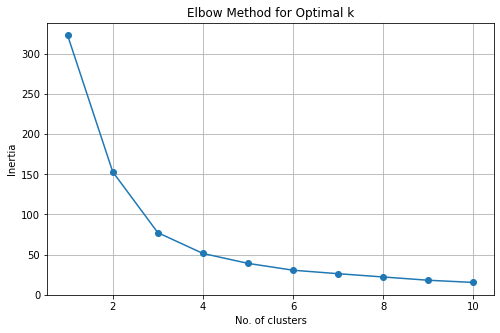

In [63]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),inertia,marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("No. of clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [67]:
#Silhoutte Scores
print("Silhoutte Scores")

k_range = range(2,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    
    score = silhouette_score(scaled_data,labels)
    print(f"k={k}, silhouette score={score:.3f}")

Silhoutte Scores
k=2, silhouette score=0.453
k=3, silhouette score=0.494
k=4, silhouette score=0.432
k=5, silhouette score=0.427
k=6, silhouette score=0.436
k=7, silhouette score=0.412
k=8, silhouette score=0.415
k=9, silhouette score=0.440
k=10, silhouette score=0.428


In [68]:
#Train FInal KMean Model
k=3
kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
data['cluster'] = kmeans.fit_predict(scaled_data)

In [69]:
#Cluster Center
centres = scaler.inverse_transform(kmeans.cluster_centers_)
center_df = pd.DataFrame(centres, columns=['price_in_thousands','4-year_resale_value'])
print("\n Cluster Centers")
print(center_df)


 Cluster Centers
   price_in_thousands  4-year_resale_value
0            3.352010             2.929788
1            3.978074             3.737702
2            2.826701             2.435155


In [70]:
#Automatically label clusters
cluster_avg = data.groupby("cluster")["price_in_thousands"].mean().sort_values()
labels = ["Economy","Mid-Range","Premium"]

cluster_map = {}

for cluster, label in zip(cluster_avg.index, labels):
    cluster_map[cluster] = label
    
print("\nCluster Labels")
print(cluster_map)

data["Segment"] = data["cluster"].map(cluster_map)


Cluster Labels
{2: 'Economy', 0: 'Mid-Range', 1: 'Premium'}


In [71]:
#Add label back to the oriinal dataset
results = df.loc[data.index].copy()

results['cluster'] = data['cluster']
results['Segment'] = data['Segment']

In [72]:
#Display sample output
print("\nCluster Dataset")

#results[
#    ["Manufacturer","Model","Price in thousands","4-year resale value","cluster","Segment"]
#].head(20)

#re


Cluster Dataset


In [73]:
#Average value of each cluster
print("\nCluster Summary")
print(data.groupby('cluster').mean())


Cluster Summary
         price_in_thousands  4-year_resale_value
cluster                                         
0                  3.352010             2.929788
1                  3.978074             3.737702
2                  2.826701             2.435155


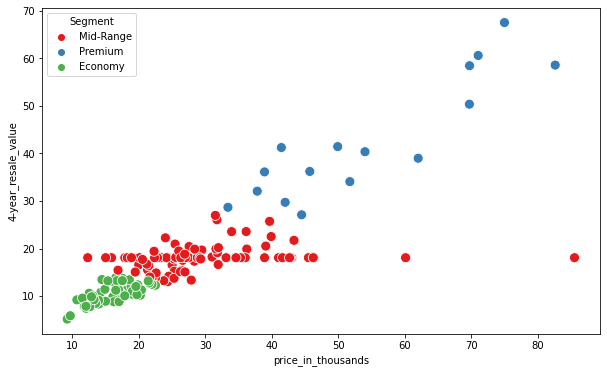

In [76]:
#Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=results,x="price_in_thousands",y="4-year_resale_value",hue ='Segment',palette="Set1",s=100)

plt.show()

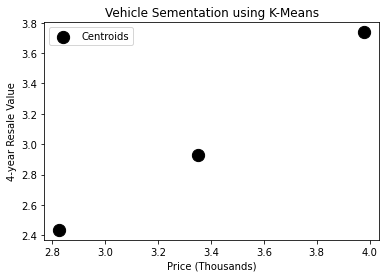

In [77]:
plt.scatter(centres[:,0],centres[:,1],color='black',marker='o',s=150,label='Centroids')

plt.title("Vehicle Sementation using K-Means")
plt.xlabel("Price (Thousands)")
plt.ylabel("4-year Resale Value")
plt.legend()
plt.show()

In [78]:
#No of vehicles in each segment
print("\nvehicles per segment")
print(results["Segment"].value_counts())


vehicles per segment
Mid-Range    88
Economy      51
Premium      16
Name: Segment, dtype: int64


In [80]:
#Interpret Segments
for i in sorted(results['Segment'].unique()):
    print("\n------------------")
    print(f"Average values for Cluster {i}")
    print("\n------------------")
    
    print(results[results['Segment'] == i][[
    "price_in_thousands",
    "4-year_resale_value"
    ]].mean())


------------------
Average values for Cluster Economy

------------------
price_in_thousands     16.225275
4-year_resale_value    10.624020
dtype: float64

------------------
Average values for Cluster Mid-Range

------------------
price_in_thousands     28.96267
4-year_resale_value    17.91099
dtype: float64

------------------
Average values for Cluster Premium

------------------
price_in_thousands     54.335188
4-year_resale_value    42.606250
dtype: float64


In [81]:
results.to_csv("Vehicle _Clusters_With_labels.csv",index=False)

print("\nDataset saved as Vehicle_Clusters_With_labels.csv")


Dataset saved as Vehicle_Clusters_With_labels.csv
